# Jaguar Re-ID — ResNet-34 Improved v8

**Architecture** : ResNet-34 (BatchNorm + ReLU, AdamW, label smoothing 0.1)  
**Changement vs 06_7** : Sweep sur Dropout (0.2, 0.3, 0.4, 0.5)  
**LR fixé** : 1e-3 | **Label smoothing fixé** : 0.1

## 1. Setup & data loading

In [17]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data import load_data, load_test_pairs, get_augmentation

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR    = os.path.join(DATA_DIR, 'cleaned')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR        = os.path.join(PROJECT_ROOT, 'tensorboards')

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 64
SEED = 42

MODEL_NAME      = 'resnet34_improved_v8'
AUGMENTATION    = 'none'
LR              = 1e-3       # Fixé (meilleur LR de 06_6)
WEIGHT_DECAY    = 5e-4
LABEL_SMOOTHING = 0.1        # Fixé (meilleur α de 06_7)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [19]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding for label smoothing
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)


## 2. Model architecture

ResNet-34 identique aux notebooks précédents, mais avec le **dropout paramétré** pour le sweep.

Interaction attendue dropout × label smoothing :
- Le **label smoothing** empêche l’explosion des logits → régularise la dernière couche
- Le **dropout** force la redondance dans les features → régularise l’avant-dernière couche (embeddings)
- Peut-être qu’avec label smoothing, un dropout plus faible (0.3, 0.2) libère de la capacité pour de meilleures features

In [20]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes, dropout_rate=0.4, augmentation='none'):
    inputs = keras.Input(input_shape)

    aug = get_augmentation(augmentation)
    x = aug(inputs) if aug is not None else inputs

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


def build_model(dropout_rate=0.4):
    return create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES,
                           dropout_rate=dropout_rate, augmentation=AUGMENTATION)

model = build_model(0.4)
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_252 (Conv2D) │ (None, 112, 112,  │      9,408 │ input_layer_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_252[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_231 (ReLU)    │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 56, 56,    │          0 │ re_lu_231[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_253 (Conv2D) │ (None, 56, 56,    │     36,864 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_253[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_232 (ReLU)    │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_254 (Conv2D) │ (None, 56, 56,    │     36,864 │ re_lu_232[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_254[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_112 (Add)       │ (None, 56, 56,    │          0 │ max_pooling2d_7[… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_233 (ReLU)    │ (None, 56, 56,    │          0 │ add_112[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_255 (Conv2D) │ (None, 56, 56,    │     36,864 │ re_lu_233[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_255[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_234 (ReLU)    │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_256 (Conv2D) │ (None, 56, 56,    │     36,864 │ re_lu_234[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_256[0][0]

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Dropout sweep

LR fixé à 1e-3, label smoothing fixé à 0.1 (meilleurs de 06_6/06_7).  
On sweep sur dropout = {0.2, 0.3, 0.4, 0.5} :
- **0.2** : peu de dropout → plus de capacité, risque d’overfitting
- **0.3** : modéré, dans le range du cours (0.1-0.45)
- **0.4** : référence (notebooks 06_1 à 06_7)
- **0.5** : agressif, hors range du cours mais classique en littérature

In [21]:
def train_and_eval(dropout_rate, run_name):
    m = build_model(dropout_rate=dropout_rate)
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=20, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val_oh, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [22]:
dropout_candidates = [0.2, 0.3, 0.4, 0.5]

results = {}
print(f"=== Dropout sweep ({MODEL_NAME}, LR={LR}, LS={LABEL_SMOOTHING}) ===")
for dp in dropout_candidates:
    run_name = f'dropout_{dp}'
    results[run_name] = train_and_eval(dp, run_name)

=== Dropout sweep (resnet34_improved_v8, LR=0.001, LS=0.1) ===


I0000 00:00:1776200582.086184  135507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2538238__.242
I0000 00:00:1776200589.947141  135509 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2538238__.242


  dropout_0.2: val_acc=0.8945 (best epoch=69)


I0000 00:00:1776200779.187109  135506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2615184__.242
I0000 00:00:1776200786.344774  135507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2615184__.242


  dropout_0.3: val_acc=0.8839 (best epoch=69)


I0000 00:00:1776200970.259648  135507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2691399__.242
I0000 00:00:1776200977.231458  135509 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2691399__.242


  dropout_0.4: val_acc=0.8892 (best epoch=76)


I0000 00:00:1776201179.349612  135506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2771306__.242
I0000 00:00:1776201186.644346  135509 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2771306__.242


  dropout_0.5: val_acc=0.8971 (best epoch=80)


In [23]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_DROPOUT = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,dropout_0.5,0.897098,80
1,dropout_0.2,0.894459,69
2,dropout_0.4,0.889182,76
3,dropout_0.3,0.883905,69



Best: dropout_0.5 → val_acc=0.8971


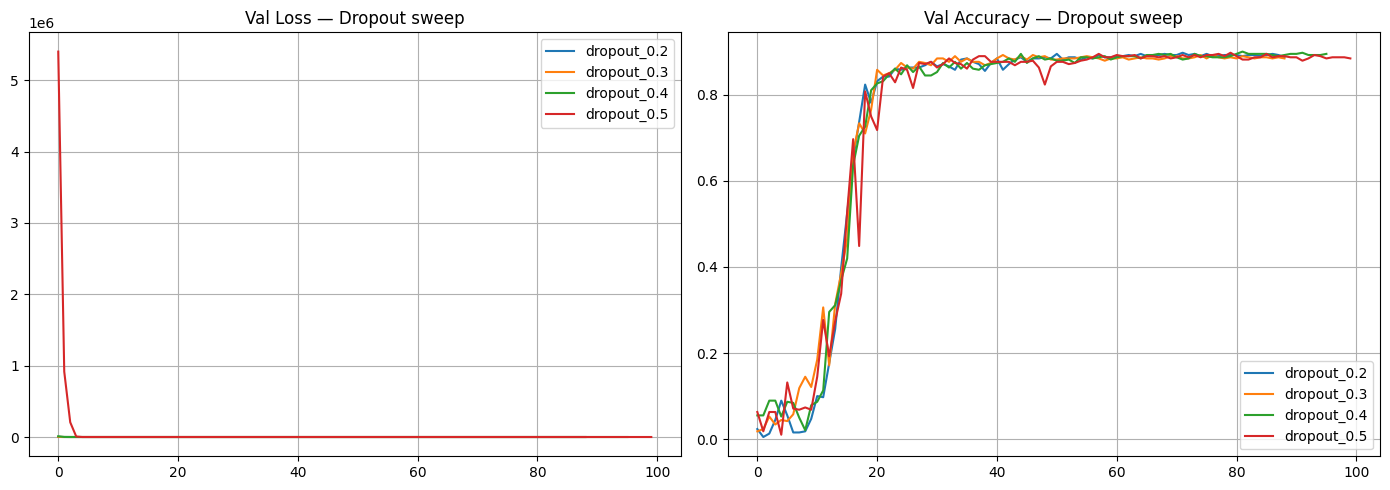

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — Dropout sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — Dropout sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_dropout_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [25]:
print(f"Retraining with best dropout = {BEST_DROPOUT}")

model = build_model(dropout_rate=BEST_DROPOUT)
model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Retraining with best dropout = 0.5
Epoch 1/100


I0000 00:00:1776201393.375447  135508 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2851082__.242


23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0892 - loss: 4.4598

I0000 00:00:1776201400.430513  135510 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2851082__.242


24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 457ms/step - accuracy: 0.1207 - loss: 3.9614 - val_accuracy: 0.0185 - val_loss: 78145136.0000 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.2058 - loss: 3.1911 - val_accuracy: 0.0106 - val_loss: 973908.9375 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.2863 - loss: 2.8044 - val_accuracy: 0.0897 - val_loss: 65842.0859 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.3892 - loss: 2.4757 - val_accuracy: 0.0897 - val_loss: 4092.5471 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.5073 - loss: 2.2195 - val_accuracy: 0.0660 - val_loss: 36.2018 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.5660 - loss: 2.0179 - val_accuracy: 0.0580 - val_loss: 7.6300 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.6299 -

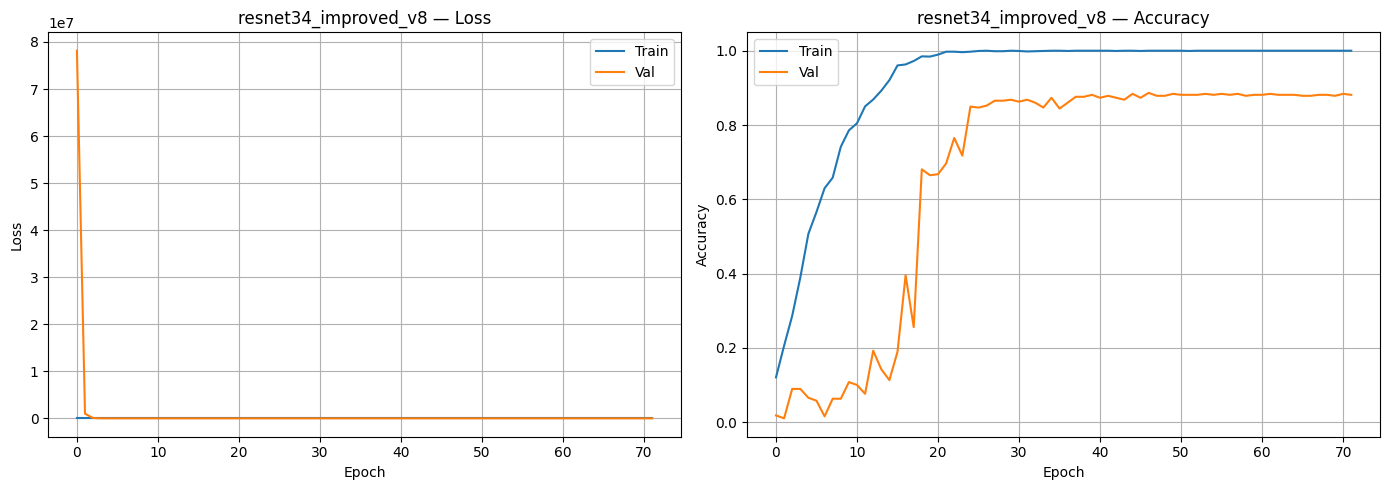

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [27]:
train_loss, train_acc = model.evaluate(X_train, y_train_oh, verbose=0)
val_loss, val_acc     = model.evaluate(X_val, y_val_oh, verbose=0)

print(f"{MODEL_NAME} (LR={LR}, LS={LABEL_SMOOTHING}, Dropout={BEST_DROPOUT}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

resnet34_improved_v8 (LR=0.001, LS=0.1, Dropout=0.5):
  Train — Loss: 0.6573, Acc: 1.0000
  Val   — Loss: 1.0391, Acc: 0.8813


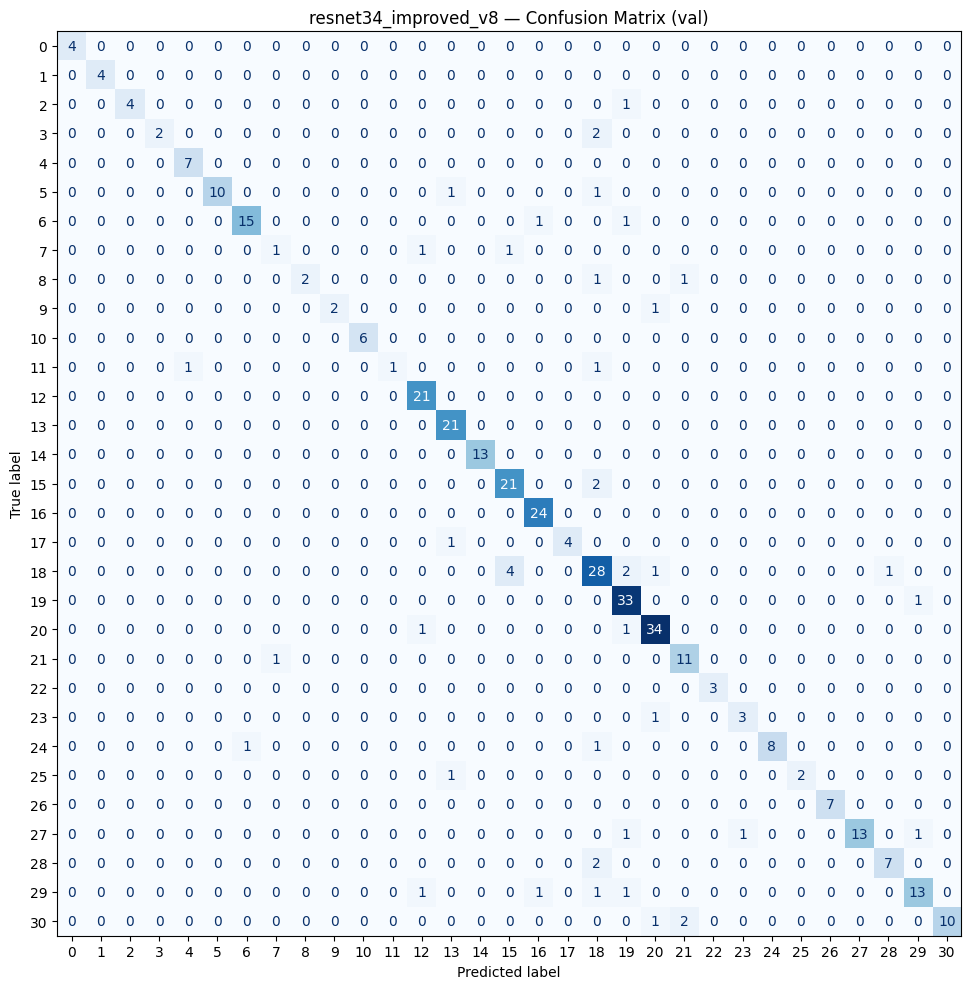

In [28]:
y_val_pred = model.predict(X_val, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [29]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")
print(f"Dropout = {BEST_DROPOUT}, Label smoothing = {LABEL_SMOOTHING}")

final_model = build_model(dropout_rate=BEST_DROPOUT)
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    X_all, y_all_oh,
    epochs=BEST_EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1
        ),
        callbacks.TensorBoard(log_dir=final_log),
    ],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(X_all, y_all_oh, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 80 epochs
Dropout = 0.5, Label smoothing = 0.1
Epoch 1/80


I0000 00:00:1776201638.635967  135506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4703067__.242


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0928 - loss: 4.4376

I0000 00:00:1776201646.449025  135507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4703067__.242


30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 260ms/step - accuracy: 0.1456 - loss: 3.8465 - learning_rate: 0.0010
Epoch 2/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3456 - loss: 2.7580 - learning_rate: 0.0010
Epoch 3/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.4686 - loss: 2.3277 - learning_rate: 0.0010
Epoch 4/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5884 - loss: 1.9692 - learning_rate: 0.0010
Epoch 5/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6580 - loss: 1.7725 - learning_rate: 0.0010
Epoch 6/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7288 - loss: 1.5774 - learning_rate: 0.0010
Epoch 7/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7462 - loss: 1.4922 - learning_rate: 0.0010
Epoch 8/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7984 - loss: 1.3414 - learning_rate: 0.0010
Epoch 9/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8433 - loss: 1.2371 - learning_rate: 0.0010
Epoch 10/80
30/30 ━━━━━━━━━━

In [30]:
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.clip(
    np.sum(test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx], axis=1),
    0, 1
)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step
Embedding shape: (371, 512)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v8.csv


,row_id,similarity
0,0,0.922237
1,1,0.757263
2,2,0.696180
3,3,0.798787
4,4,0.903892


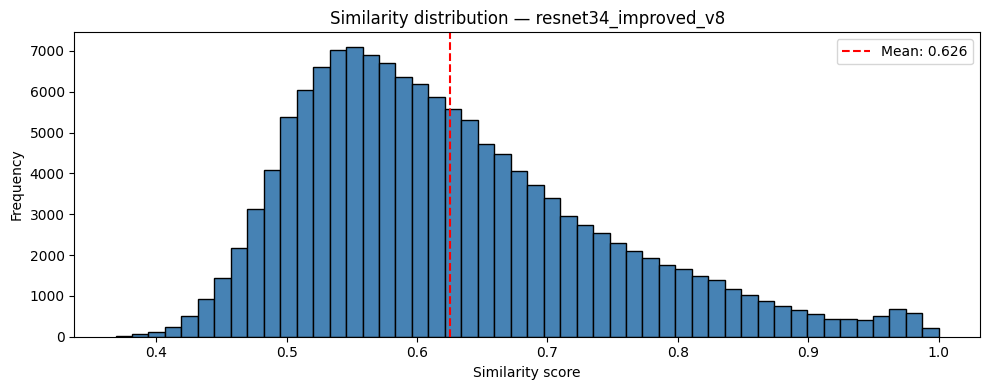

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [32]:
print(f"""
ResNet-34 improved v8 (dropout tuning):
  Best dropout: {BEST_DROPOUT}
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  LR: {LR}, Label smoothing: {LABEL_SMOOTHING}
  Best Epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}

vs 06_6 (dropout=0.4, label_smoothing=0.1):
  Val Acc: 90.77%, Kaggle: 0.636 / 0.629

Submission -> {submission_path}
""")


ResNet-34 improved v8 (dropout tuning):
  Best dropout: 0.5
  Train - Loss: 0.6573, Acc: 1.0000
  Val   - Loss: 1.0391, Acc: 0.8813
  LR: 0.001, Label smoothing: 0.1
  Best Epoch: 80
  Embedding dim: 512

vs 06_6 (dropout=0.4, label_smoothing=0.1):
  Val Acc: 90.77%, Kaggle: 0.636 / 0.629

Submission -> /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v8.csv



## 7. Observations & Verdict

### Results — Dropout Sweep

| Dropout | Val Accuracy | Best Epoch | Observation |
|---------|-------------|------------|-------------|
| 0.2 | TODO | TODO | TODO |
| 0.3 | TODO | TODO | TODO |
| **0.4** | TODO | TODO | Référence (06_6/06_7) |
| 0.5 | TODO | TODO | TODO |

### Eval finale (best dropout = TODO)

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | TODO  | TODO |
| Loss     | TODO  | TODO |
| Best epoch | TODO | |
| Retrain final acc | TODO | |
| Kaggle public | TODO | |
| Kaggle private | TODO | |

### Analysis

- TODO : Quel dropout est optimal avec label smoothing 0.1 ?
- TODO : Interaction dropout × label smoothing (les deux régularisent, synergie ou redondance ?)
- TODO : Comparaison avec 06_6/06_7 (dropout=0.4)
- TODO : Impact sur la qualité des embeddings

### Verdict

- [ ] Improvable -> Instructions for vN+1
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this architecture, why ?

### Interpretation

_Free Space : On note ce qu'on a a dire sur ce notebook, servira pour la soutenance._